In [123]:
#IMPORT LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')


In [124]:
#CHECK DATA
print(df.head())
print(df.columns)
print(df.info())

   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8       Normal   
3                 4                       30             8        Obese   
4                 4                       30             8        Obese   

  Blood Pressure  Heart Rate  Daily Steps Sleep Disorder  
0         126/83          77         4200            NaN  
1         125/80          75      

In [125]:
# DROPPING UNNECESSARY COLUMNS

df = df.drop(columns=['Person ID','Occupation'])

# Cleaning Data ( FFill na with 0 )
df = df.fillna(0)
#drop duplicates
df.drop_duplicates(inplace=True)

df.head()
print(len(df))

130


In [126]:
#SEPERATING BLOOD PRESSURE INTO SYSTOLIC AND DIASTOLIC
df[['systolic', 'diastolic']] = df['Blood Pressure'].str.split('/', expand=True)
df = df.drop(columns=['Blood Pressure'])

In [127]:
#CHECK UNIQUE VALUES IN BMI CATEGORY
df["BMI Category"].unique()

<ArrowStringArray>
['Overweight', 'Normal', 'Obese', 'Normal Weight']
Length: 4, dtype: str

In [128]:
#categorizing BMI into 0 and 1 for normal weight and overweight/obese respectively
bmi_category_map = {
    'Normal Weight': 0,
    'Normal': 0,
    'Obese': 2,
    'Overweight': 1,
}
df["BMI Category"] = df["BMI Category"].map(bmi_category_map)

disorder_catehory_map = {
    0: 0,
    'Sleep Apnea': 1,
    'Insomnia': 1,}
df["Sleep Disorder"] = df["Sleep Disorder"].map(disorder_catehory_map)
gender_map = { 'Male': 0, 'Female': 1 }
df["Gender"] = df["Gender"].map(gender_map)

In [129]:
df.head()
# Correlate Quality of Sleep and Stress Level with other features
corr_matrix = df.corr()
target_features = ['Quality of Sleep', 'Stress Level']
print(corr_matrix[target_features].abs().sort_values(by='Quality of Sleep', ascending=False))



                         Quality of Sleep  Stress Level
Quality of Sleep                 1.000000      0.883198
Stress Level                     0.883198      1.000000
Sleep Duration                   0.871505      0.831903
Heart Rate                       0.657721      0.588995
Age                              0.497316      0.415222
Sleep Disorder                   0.318499      0.221275
BMI Category                     0.315505      0.162506
Physical Activity Level          0.289708      0.106064
Gender                           0.221599      0.313572
systolic                         0.166755      0.131256
Daily Steps                      0.146036      0.116316
diastolic                        0.142783      0.121269


In [130]:
#Because blood pressure is not easy to get, we will drop it from the model
df = df.drop(columns=['systolic', 'diastolic'])

In [131]:
#Round the hours in Sleep Duration  to the nearest whole number
df['Sleep Duration'] = df['Sleep Duration'].round()

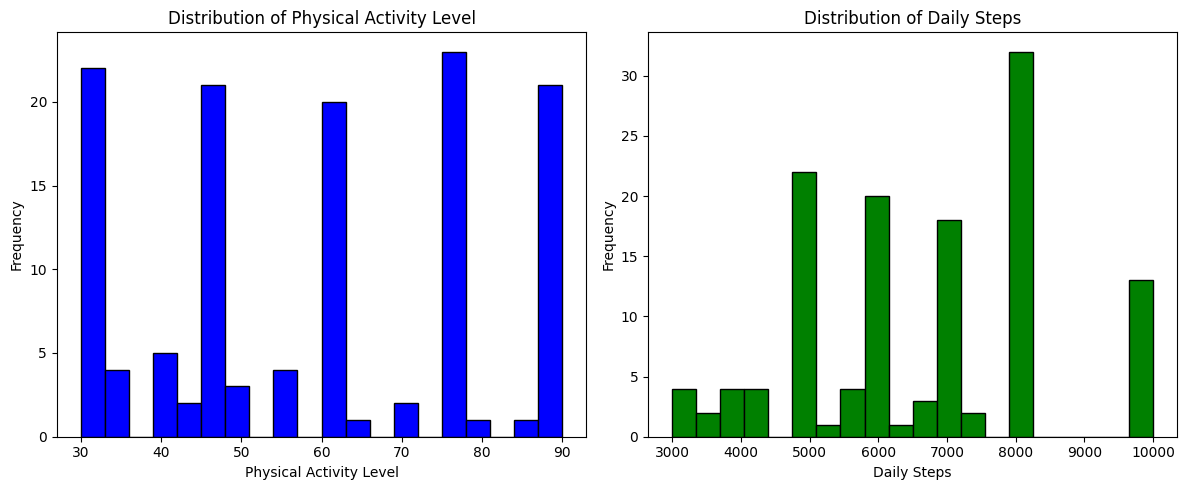

In [132]:
# Find out the ranges of screen time and daily steps using histograms
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df['Physical Activity Level'], bins=20, color='blue', edgecolor='black')
plt.title('Distribution of Physical Activity Level')
plt.xlabel('Physical Activity Level')
plt.ylabel('Frequency')
plt.subplot(1, 2, 2)
plt.hist(df['Daily Steps'], bins=20, color='green', edgecolor='black')
plt.title('Distribution of Daily Steps')
plt.xlabel('Daily Steps')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [133]:
#predictors & target variables
X = df.drop(columns=['Quality of Sleep', 'Stress Level'])
y = df[target_features]


In [134]:
X.columns

Index(['Gender', 'Age', 'Sleep Duration', 'Physical Activity Level',
       'BMI Category', 'Heart Rate', 'Daily Steps', 'Sleep Disorder'],
      dtype='str')

In [135]:
#Train Test Split and Scaling
# ADD PIPELINE

from sklearn.model_selection import train_test_split   
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline1 = Pipeline([
    ('scaler', StandardScaler()), 
    ('model', LinearRegression())
])

pipeline1.fit(X_train, y_train)
y_pred = pipeline1.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')


Mean Squared Error: 0.6310919133267192
R^2 Score: 0.6982204362313119


In [136]:
#USE XGBOOST AND RANDOM FOREST REGRESSORS to COMPARE r2 score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()), 
    ('model', RandomForestRegressor(random_state=42))
])
pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f'Random Forest Mean Squared Error: {mse_rf}')
print(f'Random Forest R^2 Score: {r2_rf}')
pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()), 
    ('model', XGBRegressor(random_state=42))
])
pipeline_xgb.fit(X_train, y_train)
y_pred_xgb = pipeline_xgb.predict(X_test)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)
print(f'XGBoost Mean Squared Error: {mse_xgb}')
print(f'XGBoost R^2 Score: {r2_xgb}')

Random Forest Mean Squared Error: 0.21678076923076917
Random Forest R^2 Score: 0.8950161424346321
XGBoost Mean Squared Error: 0.18150225281715393
XGBoost R^2 Score: 0.9088442325592041


Explaining Random Forest predictions with SHAP...
SHAP values for the first test sample (Quality of Sleep):


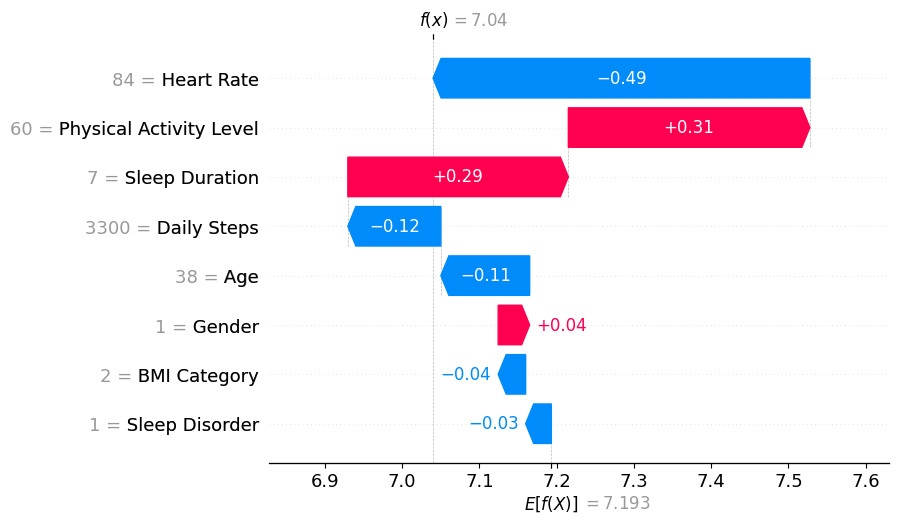

SHAP values for the first test sample (Stress Level):


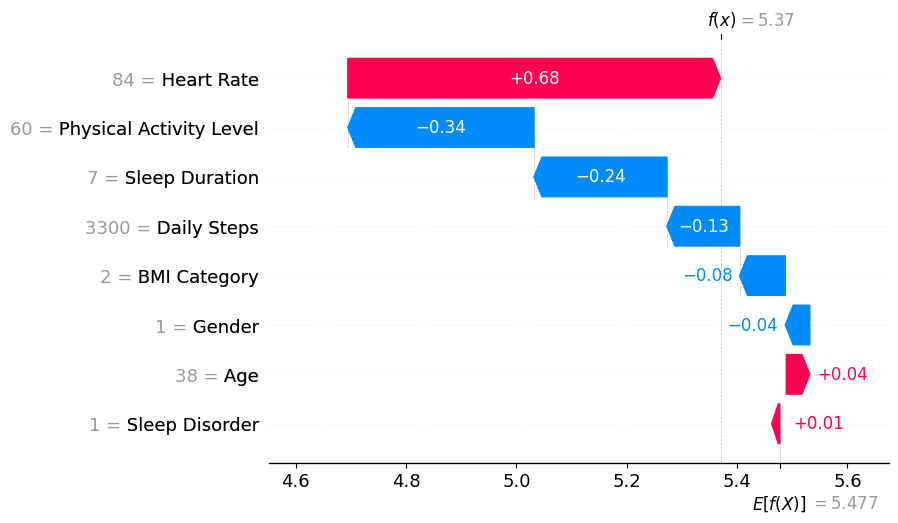

Explaining XGBoost predictions with SHAP...
SHAP values for the first test sample (Quality of Sleep):


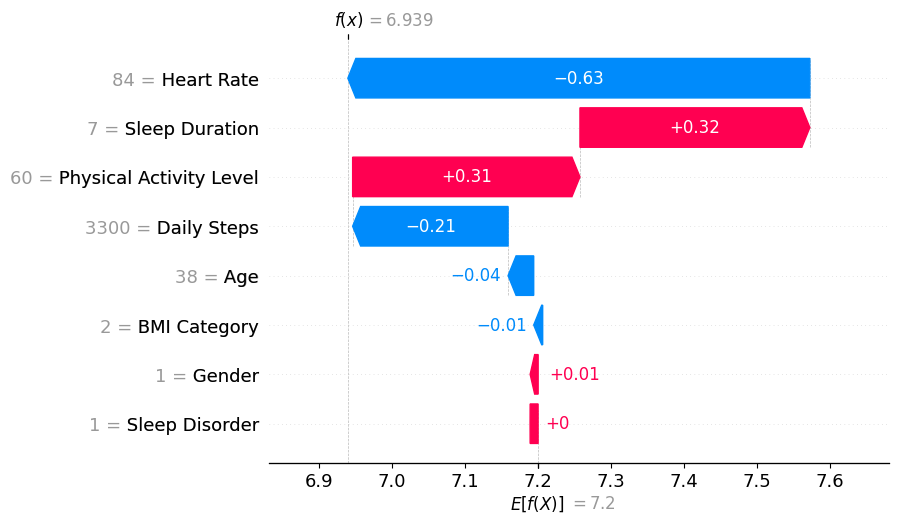

SHAP values for the first test sample (Stress Level):


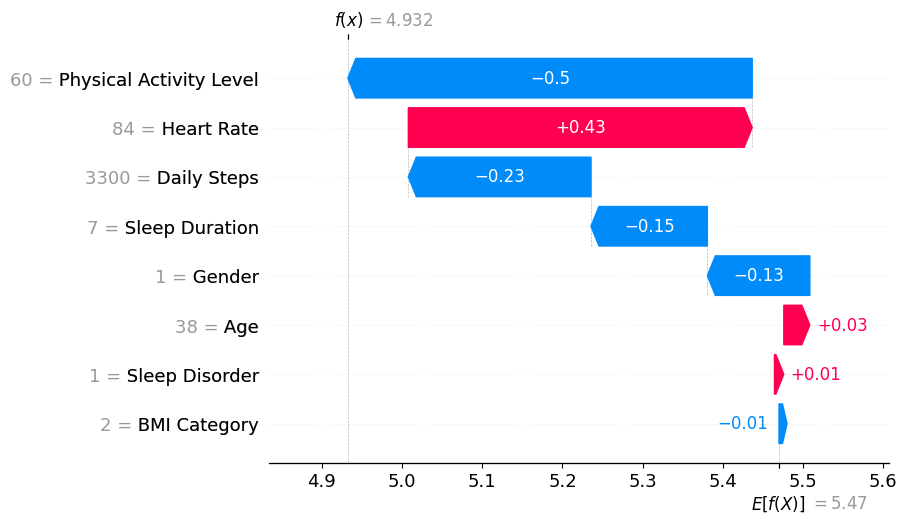

In [137]:
# SHAP FEATURES TO EXPLAIN RANDOM FOREST AND XGBOOST
import shap

# Use the pipeline prediction function so the explainer sees the same preprocessing as the model
print("Explaining Random Forest predictions with SHAP...")
explainer_rf = shap.Explainer(pipeline_rf.predict, X_train, feature_names=X.columns)
shap_values_rf = explainer_rf(X_test)
# Waterfall plot for the first test sample and first output target
print("SHAP values for the first test sample (Quality of Sleep):")
shap.plots.waterfall(shap_values_rf[0][:,0])
# If you want to compare the second target output as well, use the second column:
print("SHAP values for the first test sample (Stress Level):")
shap.plots.waterfall(shap_values_rf[0][:,1])

print("Explaining XGBoost predictions with SHAP...")
explainer_xgb = shap.Explainer(pipeline_xgb.predict, X_train, feature_names=X.columns)
shap_values_xgb = explainer_xgb(X_test)
print("SHAP values for the first test sample (Quality of Sleep):")
shap.plots.waterfall(shap_values_xgb[0][:,0])
print("SHAP values for the first test sample (Stress Level):")
shap.plots.waterfall(shap_values_xgb[0][:,1])

In [138]:
# XGBOOST MODEL WITH FULL DATASET FOR TRAINING
pipeline_xgb_full = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', XGBRegressor(random_state=42))
])
pipeline_xgb_full.fit(X, y)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None


In [2]:
#data columns to predict
X.columns

# Predict the quality of sleep and stress level for a new sample
new_sample = pd.DataFrame({
    'Gender': [1],  # 1 for female, 0 for male
    'Age': [17],
    'Sleep Duration': [8],
    'Physical Activity Level': [79],
    'BMI Category': [0],
    'Heart Rate': [70],
    'Daily Steps': [5000],
    'Sleep Disorder': [0]
})
predicted_quality_of_sleep, predicted_stress_level = pipeline_xgb_full.predict(new_sample)[0]
print(f'Predicted Quality of Sleep: {predicted_quality_of_sleep}')
print(f'Predicted Stress Level: {predicted_stress_level}')

NameError: name 'X' is not defined

In [145]:
#USE AND SAVE XGBOOST BECAUSE HAS LEAST MSE
import joblib
joblib.dump(pipeline_xgb_full, 'xgb_model.pkl')





['xgb_model.pkl']